In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import yaml
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Estilo The Economist / Banco Central ──────────────────
plt.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.grid":           True,
    "grid.color":          "#E5E5E5",
    "grid.linewidth":      0.8,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.spines.left":    False,
    "axes.spines.bottom":  True,
    "axes.edgecolor":      "#333333",
    "font.family":         "serif",
    "font.size":           11,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.labelsize":      11,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
})

# ── Cargar config central ─────────────────────────────────
cfg = yaml.safe_load(open("../config.yaml"))
DATA_PATH = Path("..") / cfg["data"]["raw_path"]

print(f"✓ Estilo cargado")
print(f"✓ Dataset esperado en: {DATA_PATH}")

✓ Estilo cargado
✓ Dataset esperado en: ..\data\raw\application_train.csv


In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dimensiones : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Target      : {cfg['project']['target_column']}")
df.head(3)

Dimensiones : 307,511 filas × 122 columnas
Memoria     : 529.5 MB
Target      : TARGET


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


✓ Carpeta model/reports/ creada


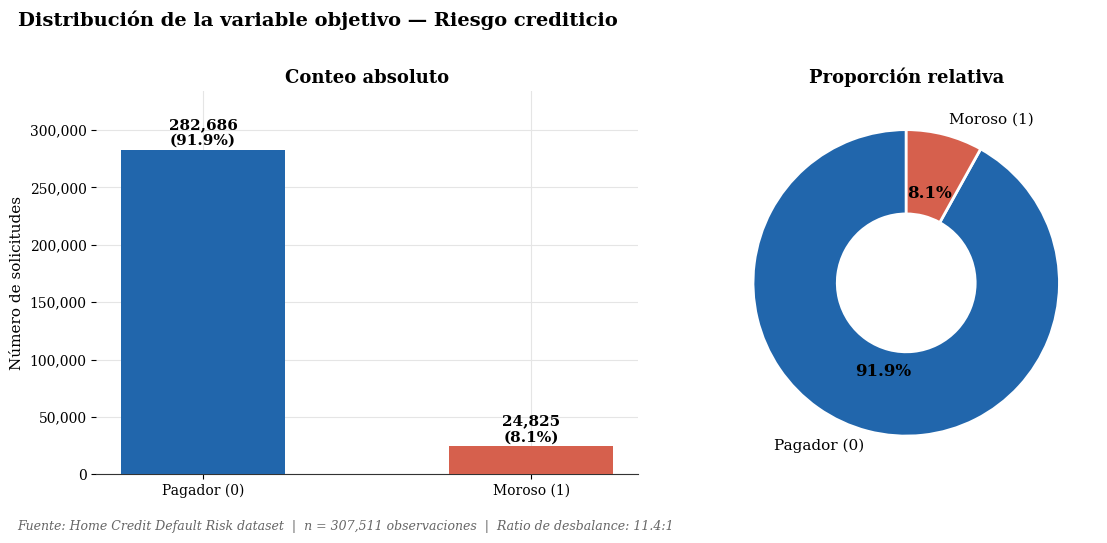

✓ Gráfica guardada en model/reports/


In [4]:
TARGET = cfg["project"]["target_column"]
conteo  = df[TARGET].value_counts()
pct     = df[TARGET].value_counts(normalize=True) * 100
etiquetas = ["Pagador (0)", "Moroso (1)"]
colores   = ["#2166AC", "#D6604D"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    "Distribución de la variable objetivo — Riesgo crediticio",
    fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.01
)

# ── Panel izquierdo: barras ───────────────────────────────
ax = axes[0]
bars = ax.bar(etiquetas, conteo.values, color=colores, width=0.5, zorder=3)
for bar, n, p in zip(bars, conteo.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1500,
            f"{n:,}\n({p:.1f}%)",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Número de solicitudes")
ax.set_title("Conteo absoluto")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, conteo.max() * 1.18)

# ── Panel derecho: donut ──────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    conteo.values,
    labels=etiquetas,
    colors=colores,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(12)
ax2.set_title("Proporción relativa")

# ── Nota al pie (estilo Banco Central) ───────────────────
fig.text(0.02, -0.03,
    f"Fuente: Home Credit Default Risk dataset  |  "
    f"n = {len(df):,} observaciones  |  "
    f"Ratio de desbalance: {conteo[0]/conteo[1]:.1f}:1",
    fontsize=9, color="#666666", style="italic")

plt.tight_layout()
from pathlib import Path
Path("../model/reports").mkdir(parents=True, exist_ok=True)
print("✓ Carpeta model/reports/ creada")
plt.savefig("../model/reports/01_class_imbalance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Gráfica guardada en model/reports/")

In [5]:
print("═" * 55)
print("  DIAGNÓSTICO DEL DATASET")
print("═" * 55)
print(f"  Total de solicitudes   : {len(df):>10,}")
print(f"  Pagadores (clase 0)    : {conteo[0]:>10,}  ({pct[0]:.1f}%)")
print(f"  Morosos   (clase 1)    : {conteo[1]:>10,}  ({pct[1]:.1f}%)")
print(f"  Ratio de desbalance    : {conteo[0]/conteo[1]:>9.1f}x")
print(f"  Variables totales      : {df.shape[1]:>10,}")
print(f"  Valores faltantes (%)  : {df.isnull().mean().mean()*100:>9.1f}%")
print("═" * 55)
print(f"\n  → SMOTE target: {cfg['smote']['sampling_strategy']*100:.0f}% morosos")

═══════════════════════════════════════════════════════
  DIAGNÓSTICO DEL DATASET
═══════════════════════════════════════════════════════
  Total de solicitudes   :    307,511
  Pagadores (clase 0)    :    282,686  (91.9%)
  Morosos   (clase 1)    :     24,825  (8.1%)
  Ratio de desbalance    :      11.4x
  Variables totales      :        122
  Valores faltantes (%)  :      24.4%
═══════════════════════════════════════════════════════

  → SMOTE target: 30% morosos
